# Anotación de DEGs de lubina mediante resultados BLAST
## TFM — Biomarcadores transcriptómicos de eficiencia digestiva en dorada y lubina
### Autor: Ángel López Francés | Universidad de Murcia

---

## Objetivo
Cruzar los DEGs de lubina (GSE59240) con los resultados de BLAST (formato Hit Table)
para obtener los accession numbers de RefSeq asociados a cada sonda del microarray.

**Archivos necesarios:**
- `DEGs_lubina_anotados.csv` — generado en notebook `TFM_Lubina_Anotacion_DEGs.ipynb`
- `Z9HMPAJW014-Alignment-HitTable.csv` — descargado de NCBI BLAST (formato Hit Table CSV)


## 1. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
sns.set_style('whitegrid')
print(' Librerías importadas')

 Librerías importadas


## 2. Carga del HitTable de BLAST

El formato Hit Table de NCBI BLAST tiene 12 columnas estándar:

| Col | Nombre | Descripción |
|-----|--------|-------------|
| 1 | query_full | ID de la sonda (con metadatos) |
| 2 | subject_acc | Accession RefSeq del hit |
| 3 | pct_identity | % identidad |
| 4 | alignment_length | Longitud del alineamiento |
| 5-6 | mismatches/gaps | Errores |
| 7-10 | q/s start/end | Posiciones del alineamiento |
| 11 | evalue | E-value (significancia estadística) |
| 12 | bit_score | Bit score |

**Criterios de calidad del hit:**
- % identidad ≥ 95%
- E-value < 1e-10
- Para hits múltiples por gen: se conserva el de mayor identidad y menor e-value

In [3]:
# Leer HitTable
blast_raw = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\Z9HMPAJW014-Alignment-HitTable.csv', header=None,
    names=['query_full','subject_acc','pct_identity','alignment_length',
           'mismatches','gap_opens','q_start','q_end','s_start','s_end',
           'evalue','bit_score'])

print(f'Total de hits BLAST: {len(blast_raw):,}')
print(f'Columnas: {blast_raw.columns.tolist()}')
print(f'\nPrimeras filas:')
blast_raw.head()

Total de hits BLAST: 174
Columnas: ['query_full', 'subject_acc', 'pct_identity', 'alignment_length', 'mismatches', 'gap_opens', 'q_start', 'q_end', 's_start', 's_end', 'evalue', 'bit_score']

Primeras filas:


,query_full,subject_acc,pct_identity,alignment_length,mismatches,gap_opens,q_start,q_end,s_start,s_end,evalue,bit_score
0,L3_83747|AltoANT-MED_digestion-absorcion|FC_AN...,XR_007885885.1,100.000,60,0,0,1,60,9886,9945,1.790000e-24,111.0
1,L2_28353|AltoANT-MED_digestion-absorcion|FC_AN...,XR_007885885.1,98.333,60,1,0,1,60,2587,2528,8.310000e-23,106.0
2,L12_34593|AltoANT-MED_digestion-absorcion|FC_A...,XM_051390030.1,98.333,60,1,0,1,60,213,272,8.310000e-23,106.0
3,L12_89941|AltoANT-MED_digestion-absorcion|FC_A...,XR_007885885.1,100.000,60,0,0,1,60,3190,3249,1.790000e-24,111.0
4,L12_84913|AltoANT-MED_digestion-absorcion|FC_A...,XM_051411637.1,100.000,30,0,0,1,30,1613,1642,8.490000e-08,56.5


## 3. Parseo del campo query

El campo `query_full` contiene el ID de sonda y metadatos separados por `|` que añadimos
al generar el FASTA. Los extraemos para poder cruzar con los DEGs.

Genes únicos en BLAST: 94
% identidad media: 99.5%
Rango e-value: 1.79e-24 — 3.05e-07


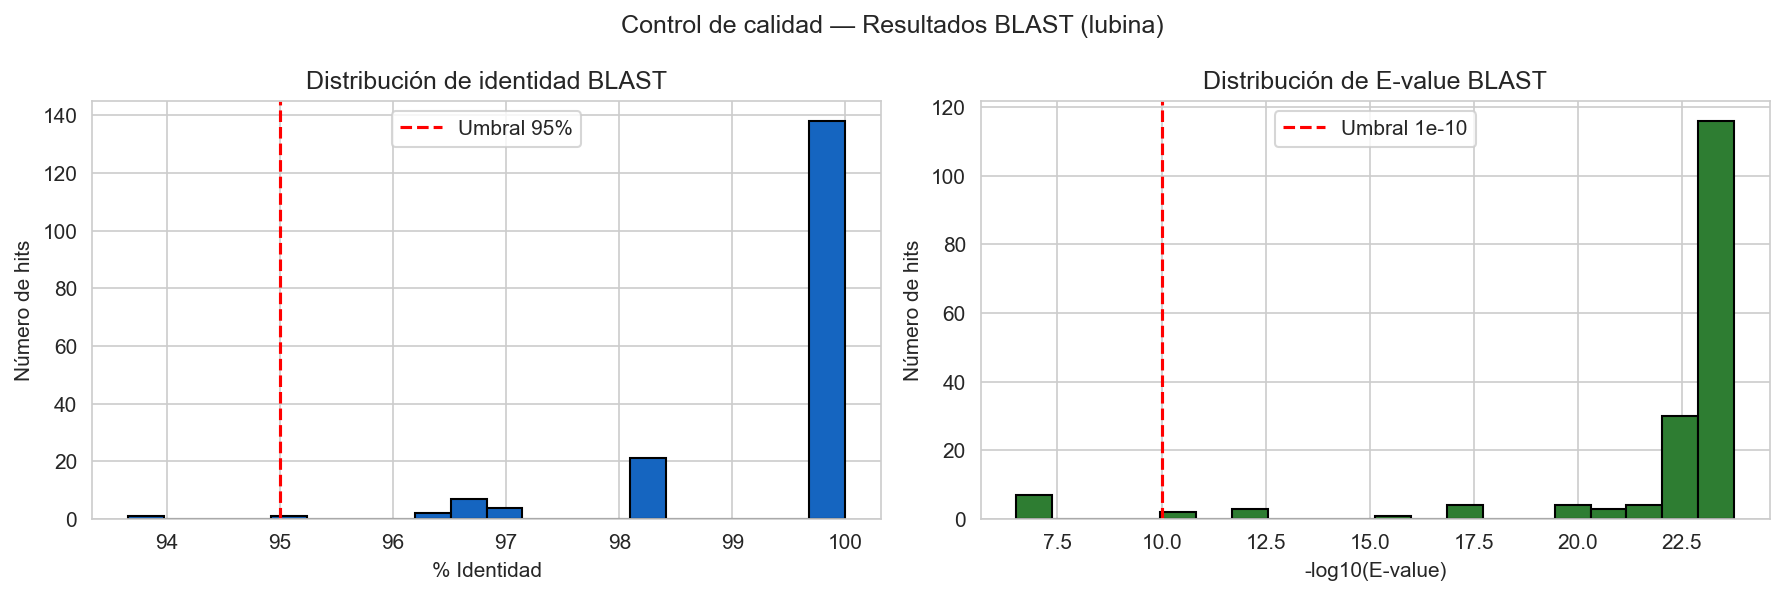

Figura guardada: QC_BLAST_lubina.png


In [4]:
# Extraer campos del query_full
# Formato: GeneID|Patron|FC_ANT_POS=X.XX|FDR=X.XXe-XX
blast_raw['GeneID']     = blast_raw['query_full'].str.split('|').str[0]
blast_raw['Patron']     = blast_raw['query_full'].str.split('|').str[1]
blast_raw['FC_ANT_POS'] = blast_raw['query_full'].str.extract(r'FC_ANT_POS=([0-9.\-]+)').astype(float)
blast_raw['FDR']        = blast_raw['query_full'].str.extract(r'FDR=([0-9.e\-]+)').astype(float)

print(f'Genes únicos en BLAST: {blast_raw["GeneID"].nunique()}')
print(f'% identidad media: {blast_raw["pct_identity"].mean():.1f}%')
print(f'Rango e-value: {blast_raw["evalue"].min():.2e} — {blast_raw["evalue"].max():.2e}')

# Distribución de identidades
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(blast_raw['pct_identity'], bins=20, color='#1565C0', edgecolor='black')
axes[0].set_xlabel('% Identidad')
axes[0].set_ylabel('Número de hits')
axes[0].set_title('Distribución de identidad BLAST')
axes[0].axvline(95, color='red', linestyle='--', label='Umbral 95%')
axes[0].legend()

axes[1].hist(-np.log10(blast_raw['evalue'] + 1e-30), bins=20, color='#2E7D32', edgecolor='black')
axes[1].set_xlabel('-log10(E-value)')
axes[1].set_ylabel('Número de hits')
axes[1].set_title('Distribución de E-value BLAST')
axes[1].axvline(10, color='red', linestyle='--', label='Umbral 1e-10')
axes[1].legend()

plt.suptitle('Control de calidad — Resultados BLAST (lubina)', fontsize=12)
plt.tight_layout()
plt.savefig('QC_BLAST_lubina.png', bbox_inches='tight')
plt.show()
print('Figura guardada: QC_BLAST_lubina.png')

## 4. Filtrado y selección del mejor hit por gen

In [ ]:
# Filtrar por calidad
UMBRAL_IDENTIDAD = 90   # % mínimo de identidad
UMBRAL_EVALUE    = 1e-5 # e-value máximo

blast_filtrado = blast_raw[
    (blast_raw['pct_identity'] >= UMBRAL_IDENTIDAD) &
    (blast_raw['evalue'] <= UMBRAL_EVALUE)
].copy()

print(f'Hits antes del filtrado:  {len(blast_raw):,}')
print(f'Hits después del filtrado: {len(blast_filtrado):,}')

# Seleccionamos el MEJOR hit por gen
blast_best = (
    blast_filtrado
    .sort_values(['GeneID', 'pct_identity', 'evalue'],
                  ascending=[True, False, True])
    .drop_duplicates('GeneID', keep='first')
)

print(f'\nGenes con hit de calidad: {len(blast_best):,}')
print(f'Identidad media (mejores hits): {blast_best["pct_identity"].mean():.2f}%')
print(f'\nTop 10 hits más significativos:')
blast_best.nsmallest(10, 'evalue')[['GeneID','subject_acc','pct_identity',
                                     'evalue','FC_ANT_POS','FDR']]

Hits antes del filtrado:  174
Hits después del filtrado: 174

Genes con hit de calidad: 94
Identidad media (mejores hits): 99.54%

Top 10 hits más significativos:


,GeneID,subject_acc,pct_identity,evalue,FC_ANT_POS,FDR
24,L12_39581,XM_051386316.1,100.0,1.790000e-24,4.28,4.730000e-11
19,L12_59073,XM_051407222.1,100.0,1.790000e-24,11.05,2.030000e-11
113,L12_59925,XM_051378720.1,100.0,1.790000e-24,3.36,3.710000e-08
153,L12_64530,XM_051396035.1,100.0,1.790000e-24,1.64,8.870000e-08
25,L12_66506,XM_051413564.1,100.0,1.790000e-24,8.65,6.670000e-11
54,L12_72937,XM_051390817.1,100.0,1.790000e-24,4.43,4.250000e-10
67,L12_73756,XM_051384715.1,100.0,1.790000e-24,4.86,3.790000e-09
48,L12_73826,XM_051420001.1,100.0,1.790000e-24,4.68,3.600000e-10
53,L12_75419,XM_051402336.1,100.0,1.790000e-24,3.54,3.880000e-10
162,L12_76473,XM_051427274.1,100.0,1.790000e-24,2.24,1.420000e-07


## 5. Cruce con los DEGs de lubina

In [ ]:
# Cargar DEGs anotados (del notebook anterior)
degs = pd.read_csv('C:\\Users\\angel\\Desktop\\blast y anotacion completa\\subir\\lubina\\DEGs_lubina_anotados.csv', index_col=0)

print(f'DEGs cargados: {len(degs):,}')
print(f'Columnas: {degs.columns.tolist()}')

# Cruzar DEGs con resultados BLAST
degs_anotados = degs.merge(
    blast_best[['GeneID', 'subject_acc', 'pct_identity', 'evalue', 'bit_score']],
    left_index=True,
    right_on='GeneID',
    how='left'
).set_index('GeneID')

n_anotados  = degs_anotados['subject_acc'].notna().sum()
n_sin_anotar = degs_anotados['subject_acc'].isna().sum()

print(f'\n Resultado del cruce:')
print(f'   DEGs con accession BLAST: {n_anotados} ({n_anotados/len(degs_anotados)*100:.1f}%)')
print(f'   DEGs sin anotar:          {n_sin_anotar} ({n_sin_anotar/len(degs_anotados)*100:.1f}%)')

DEGs cargados: 4,613
Columnas: ['pvalue', 'padj', 'media_ANT', 'media_MED', 'media_POS', 'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED', 'Patron', 'SEQUENCE']

 Resultado del cruce:
   DEGs con accession BLAST: 94 (2.0%)
   DEGs sin anotar:          4519 (98.0%)


## 6. Tabla de DEGs anotados — resumen por patrón

In [ ]:
# Ver genes anotados por patrón
cols_mostrar = ['padj', 'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'Patron',
                'subject_acc', 'pct_identity', 'evalue']

print('=== GENES ALTO EN ANT-MED (digestión y absorción) ===')
ant_med = degs_anotados[
    (degs_anotados['Patron'] == 'Alto_ANT-MED') &
    (degs_anotados['subject_acc'].notna())
].sort_values('padj')
print(f'Total: {len(ant_med)}')
print(ant_med[cols_mostrar].head(20).to_string())

print('\n=== GENES ALTO EN POS (transporte iónico e inmunidad) ===')
pos = degs_anotados[
    (degs_anotados['Patron'] == 'Alto_POS') &
    (degs_anotados['subject_acc'].notna())
].sort_values('padj')
print(f'Total: {len(pos)}')
print(pos[cols_mostrar].head(20).to_string())

=== GENES ALTO EN ANT-MED (digestión y absorción) ===
Total: 94
                   padj  FC_ANT_vs_POS  FC_MED_vs_POS        Patron     subject_acc  pct_identity        evalue
GeneID                                                                                                         
L3_83747   2.903515e-14       5.102783       5.098997  Alto_ANT-MED  XR_007885885.1       100.000  1.790000e-24
L2_28353   2.903515e-14       6.144814       6.139177  Alto_ANT-MED  XR_007885885.1        98.333  8.310000e-23
L12_34593  1.376561e-13       9.545505       9.542132  Alto_ANT-MED  XM_051390030.1        98.333  8.310000e-23
L12_89941  8.816866e-13       6.851308       6.635545  Alto_ANT-MED  XR_007885885.1       100.000  1.790000e-24
L12_84913  2.196596e-12       5.559144       5.519264  Alto_ANT-MED  XM_051411637.1       100.000  8.490000e-08
L12_85179  4.064441e-12       5.769280       5.825103  Alto_ANT-MED  XM_051426087.1       100.000  2.310000e-23
L12_81434  5.256850e-12       7.328828  

## 7. Exportar tabla final completa

In [ ]:
# Exportar tabla completa con accessions
columnas_exportar = [
    'pvalue', 'padj',
    'media_ANT', 'media_MED', 'media_POS',
    'FC_ANT_vs_POS', 'FC_MED_vs_POS', 'FC_ANT_vs_MED',
    'Patron',
    'subject_acc', 'pct_identity', 'evalue', 'bit_score'
]

# Solo columnas que existen
cols_ok = [c for c in columnas_exportar if c in degs_anotados.columns]
tabla_final = degs_anotados[cols_ok].sort_values('padj')
tabla_final.to_csv('DEGs_lubina_con_accession.csv')

# Exportar solo los anotados para la comparativa con dorada
tabla_anotados = tabla_final[tabla_final['subject_acc'].notna()]
tabla_anotados.to_csv('DEGs_lubina_anotados_BLAST.csv')

print('Archivos exportados:')
print(f'   DEGs_lubina_con_accession.csv    — {len(tabla_final):,} DEGs (todos)')
print(f'   DEGs_lubina_anotados_BLAST.csv   — {len(tabla_anotados):,} DEGs (solo con accession)')
print(f'\nDistribución de anotados por patrón:')
print(tabla_anotados.groupby('Patron').size().to_string())

Archivos exportados:
   DEGs_lubina_con_accession.csv    — 4,613 DEGs (todos)
   DEGs_lubina_anotados_BLAST.csv   — 94 DEGs (solo con accession)

Distribución de anotados por patrón:
Patron
Alto_ANT-MED    94


## 8. Cómo obtener los nombres de genes a partir de los accessions

Los accession numbers tipo `XM_051390030.1` son transcriptos de RefSeq de *D. labrax*.
Para obtener el nombre del gen hay dos métodos pero usamos:

### Método — Batch Entrez 
1. En https://www.ncbi.nlm.nih.gov/sites/batchentrez
2. Con la base de datos: **Nucleotide**
3. Subimos nuestro archivo `accessions_lubina.txt` generado 
4. Descargamos en formato **Summary** 



In [12]:
# Exportar lista de accessions para Batch Entrez o BioMart
accessions = tabla_anotados['subject_acc'].dropna().unique()

with open('accessions_lubina.txt', 'w') as f:
    f.write('\n'.join(accessions))

print(f'Archivo exportado: accessions_lubina.txt')
print(f'   Total accessions únicos: {len(accessions)}')
print(f'\nPrimeros 20 accessions:')
for acc in accessions[:20]:
    print(f'   {acc}')


Archivo exportado: accessions_lubina.txt
   Total accessions únicos: 88

Primeros 20 accessions:
   XR_007885885.1
   XM_051390030.1
   XM_051411637.1
   XM_051426087.1
   XM_051404768.1
   XR_007883313.1
   XM_051407115.1
   XM_051380307.1
   XM_051375258.1
   XM_051418622.1
   XM_051407222.1
   XM_051375819.1
   XM_051428054.1
   XM_051426151.1
   XM_051386316.1
   XM_051413564.1
   XM_051406384.1
   XM_051404293.1
   XM_051418546.1
   XM_051393016.1


## 9. Resumen del pipeline completo de anotación

| Paso | Herramienta | Archivo generado |
|------|-------------|------------------|
| 1 | `TFM_Lubina_Microarray.ipynb` | `DEGs_lubina_intestino.csv` |
| 2 | `TFM_Lubina_Anotacion_DEGs.ipynb` | `DEGs_lubina_anotados.csv`, archivos FASTA |
| 3 | NCBI BLAST  | `Z9HMPAJW014-Alignment-HitTable.csv` |
| 4 | **Este notebook** | `DEGs_lubina_con_accession.csv`, `accessions_lubina.txt` |
| 5 | NCBI Batch Entrez / BioMart | Nombres de genes + descripción funcional |


In [11]:
import sys
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Python: 3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 12:58:53) [MSC v.1929 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.0.1
